# Identification of Jets at the LHC

In particle physics jets are the collection of hadronic particles (e.g. particles containing quarks) observed in a collider detector which are assocaited with an initial high momentum particle.

Numerous particle physics discoveries over the past 50 years have involved measurements of jets. From the [observation of the gluon](https://home.cern/news/news/physics/four-decades-gluons) to searches for [rare Higgs bosons decays to tau leptons](https://atlas.cern/Updates/Briefing/rare-Higgs-tau-interaction). In both of these cases the particle initiating the jet does not itself contain quarks but either through decay or interaction a hadronic jet is produced.


## Data

We will be using a publicly available dataset called HLS4ML. This [dataset is available on Zenodo](https://zenodo.org/doi/10.5281/zenodo.3602253)

## Looking at the data

The data consists of a number of 100x100 pixel images that represent how the jet looks inside the detector. In this miniproject you will take images of simulated jets and attempt to classify them into various categories based on the originating particle and its properties.


### A brief description of the variables in the Jet Features
This is not a particle physics course, you did not to understand any pr all of the variables. Some of the variables are described in the table below it is particularly important to understand how to use the five flags at the end that tell which type of event the image corresponds to. If you would like to learn more about jet substructure you can [skim read this nice phenomological review](https://arxiv.org/abs/1901.10342).

| Variable      | Description |
| ----------- | ----------- |
| j_pt      | The transverse momentum of the jet   |
| j_eta      | The (pseudo)rapidity of the jet  |
| j_mass     | The jet mass  |
| j_tau*   | A jet shape variable        |
| j_c*   | A jet shape variable        |
| j_mass_*   | A jet mass variable      |
| j_multiplicity   | The number of particles in the jet      |
| j_g      | Was this jet initiated by a gluon?  |
| j_q      | Was this jet initiated by a (light) quark?   |
| j_w      | Was this jet initiated by a W-boson?    |
| j_z      | Was this jet initiated by a Z-boson?   |
| j_t      | Was this jet initiated by a top quark?    |



## Machine learning tasks
1. Develop a machine learning classifier that can separate the five classes of event lsited above (Gluon, Quark, W-Boson, Z-Boson, Top) using only the combined jetImage image
2. Test your machine learning classifier and investigate how the efficiency of the classifier depends on the jet feature variables shown above. Which classes of event art the easiest to separate?

### Potential potional extensions
1. Extend your machine learning classifier to take in the three jet images (jetImage, jetImageECAL, jetImageHCAL)
2. Compare your machine learning classifier to one that just uses the jet features (no image input)
3. Develop a combined classifier that takes both images and features

### Things to remember
A reminder that this is a machine learning for physicists course, but with the project we are mostly testing your application of machine learning.

Some things to consider:
* What type of data preparation do you need?
* Do you need to do anything to the images to make them useful?
* When/if you are using the jet features how should you use them?
* How will you split the data in training, validation and testing samples?
* How will you ensure that your model is not over-fitting to the training sample?
* What is the best way to display the performance of your classifier?



In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# List everything in the top level of your Drive
for item in sorted(os.listdir('/content/drive/MyDrive/Physics 3rd Yr/PHAS0056: Machine Learning/Final Proj/data_files/train')):
    print(item)

main_dir = '/content/drive/MyDrive/Physics 3rd Yr/PHAS0056: Machine Learning/Final Proj/' #main directory on Google Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
jetImage_0_100p_0_10000.h5
jetImage_0_100p_10000_20000.h5
jetImage_0_100p_20000_30000.h5
jetImage_0_100p_30000_40000.h5
jetImage_0_100p_40000_50000.h5
jetImage_0_100p_50000_60000.h5
jetImage_0_100p_60000_70000.h5
jetImage_0_100p_70000_80000.h5
jetImage_0_100p_80000_90000.h5
jetImage_1_100p_0_10000.h5
jetImage_1_100p_10000_20000.h5
jetImage_1_100p_20000_30000.h5
jetImage_1_100p_30000_40000.h5
jetImage_1_100p_40000_50000.h5
jetImage_1_100p_50000_60000.h5
jetImage_1_100p_60000_70000.h5
jetImage_1_100p_70000_80000.h5
jetImage_1_100p_80000_90000.h5
jetImage_2_100p_0_10000.h5
jetImage_2_100p_10000_20000.h5
jetImage_2_100p_20000_30000.h5
jetImage_2_100p_30000_40000.h5
jetImage_2_100p_40000_50000.h5
jetImage_2_100p_50000_60000.h5
jetImage_2_100p_60000_70000.h5
jetImage_2_100p_70000_80000.h5
jetImage_2_100p_80000_90000.h5
jetImage_3_100p_0_10000.h5
jetImage_3_100p_100

In [2]:
import h5py
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.utils import shuffle
print(os.getcwd())


/content


In [3]:
import tensorflow as tf
print(tf)
print(getattr(tf, "__file__", "no file location"))

<module 'tensorflow' from '/usr/local/lib/python3.12/dist-packages/tensorflow/__init__.py'>
/usr/local/lib/python3.12/dist-packages/tensorflow/__init__.py


In [4]:
import sys
print(sys.executable)

/usr/bin/python3


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import math

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

import matplotlib.style
import matplotlib as mpl
from scipy import linalg


#Set default figure size
#mpl.rcParams['figure.figsize'] = [12.0, 8.0] #Inches... of course it is inches
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=200 # dots per inch

#Useful for debugging problems
print(tf.__version__)
print(np.__version__)

2.19.0
2.0.2


In [6]:
print("GPUs:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


In [7]:
#For this notebook to work you will need to download at least one of the jetImage files
#For the project you will end up using more than one file

# import the urllib library
import urllib.request
import os


firstFile= main_dir + '/data_files/train/jetImage_0_100p_0_10000.h5'

if not os.path.isfile(firstFile):
    if not os.path.isdir('./data_files/train'):
        os.makedirs('./data_files/train')

    # Correct the URL construction: remove '/content/' from firstFile for the URL part
    download_url_path = firstFile.replace('/content/', '')
    base_download_url = 'http://www.hep.ucl.ac.uk/undergrad/0056/other/projects/jetimage/'
    full_download_url = base_download_url + download_url_path
    # Copy a network object to a local file
    urllib.request.urlretrieve(full_download_url, firstFile)


#Open the local h5 file with h5py
df=h5py.File(firstFile,'r')
print(df.keys())
print(type(df))

<KeysViewHDF5 ['jetConstituentList', 'jetFeatureNames', 'jetImage', 'jetImageECAL', 'jetImageHCAL', 'jets', 'particleFeatureNames']>
<class 'h5py._hl.files.File'>


In [8]:
df["jetImage"].shape

(10000, 100, 100)

<HDF5 dataset "jetImage": shape (10000, 100, 100), type "<f8">


Text(0.5, 1.0, 'HCAL Image')

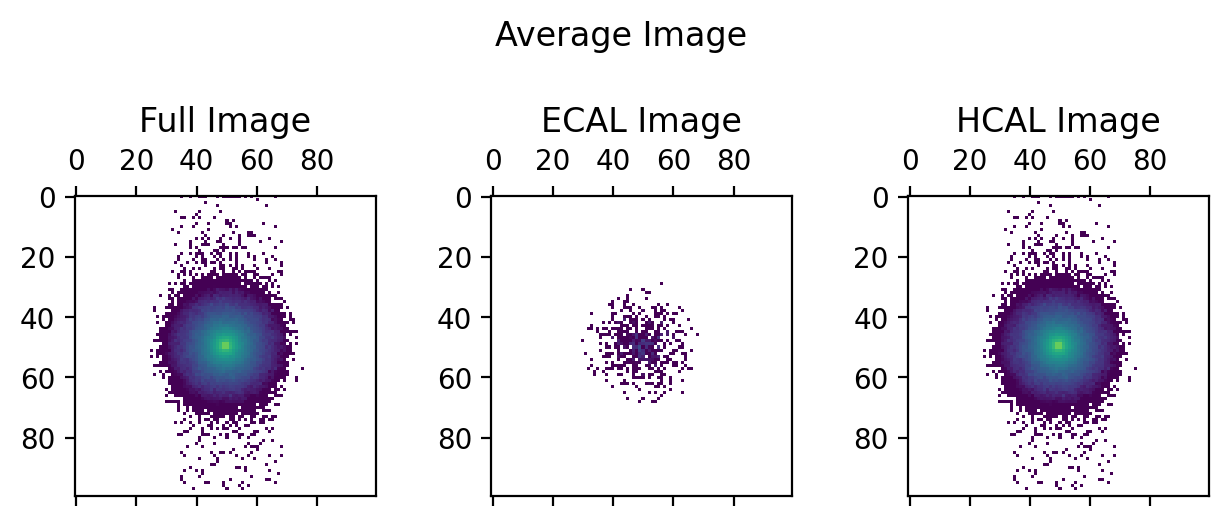

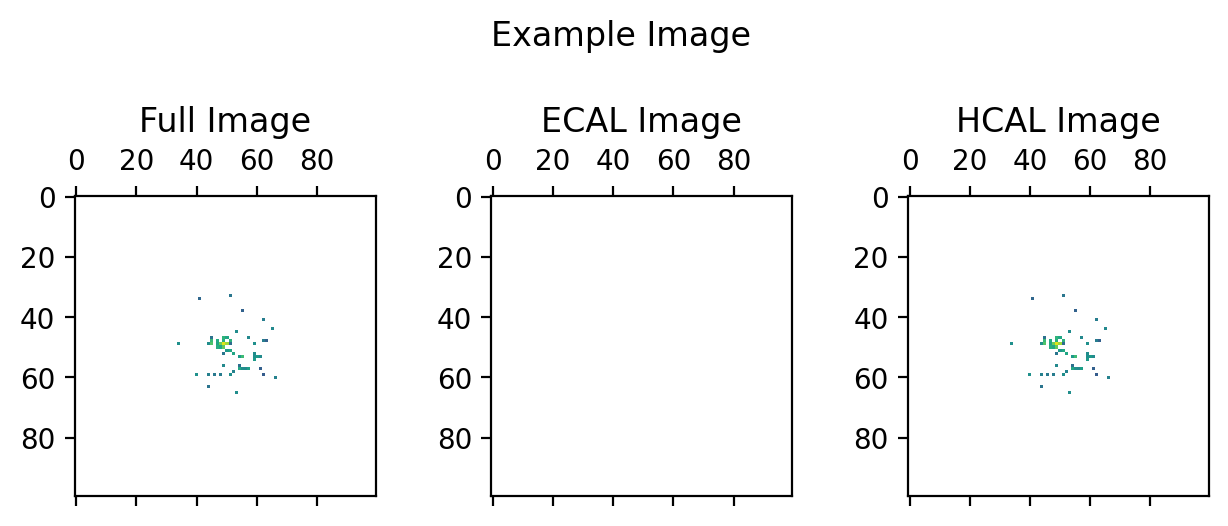

In [9]:
print(df['jetImage'])
fig, ax = plt.subplots(1,3)
plt.tight_layout()
plt.suptitle("Average Image")
plt.subplots_adjust(top=1.2)
ax[0].matshow(np.mean(df['jetImage'][:],axis=0),norm=LogNorm(vmin=0.01, vmax=1e3))
ax[0].set_title("Full Image")
ax[1].matshow(np.mean(df['jetImageECAL'][:],axis=0),norm=LogNorm(vmin=0.01, vmax=1e3))
ax[1].set_title("ECAL Image")
ax[2].matshow(np.mean(df['jetImageHCAL'][:],axis=0),norm=LogNorm(vmin=0.01, vmax=1e3))
ax[2].set_title("HCAL Image")


fig, ax = plt.subplots(1,3)
plt.tight_layout()
plt.subplots_adjust(top=1.2)
plt.suptitle("Example Image")
ax[0].matshow(df['jetImage'][0],norm=LogNorm(vmin=0.01, vmax=1e3))
ax[0].set_title("Full Image")
ax[1].matshow(df['jetImageECAL'][0],norm=LogNorm(vmin=0.01, vmax=1e3))
ax[1].set_title("ECAL Image")
ax[2].matshow(df['jetImageHCAL'][0],norm=LogNorm(vmin=0.01, vmax=1e3))
ax[2].set_title("HCAL Image")

In [10]:
# Now we are going to load the jet features into pandas dataframe

# The labels of the Jet Features are in the key jetFeatureNames
# we will load this into a simple list of strings
labels=[label.decode("utf-8") for label in df['jetFeatureNames'][:] ]

# Now we can load it into a pandas dataframe with the labels
pJet = pd.DataFrame(np.array(df['jets']),columns=labels)
pJet.describe()
#print(labels)



,j_ptfrac,j_pt,j_eta,j_mass,j_tau1_b1,j_tau2_b1,j_tau3_b1,j_tau1_b2,j_tau2_b2,j_tau3_b2,...,j_mass_prun,j_mass_sdb2,j_mass_sdm1,j_multiplicity,j_g,j_q,j_w,j_z,j_t,j_undef
count,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0
mean,1.0,1046.172307,-0.005088,94.966652,63.847302,25.478940,16.431138,9.921416,2.732791,1.217323,...,75.147261,91.540507,11.868058,52.334500,0.20720,0.18850,0.201000,0.193100,0.210200,0.0
std,0.0,126.132566,0.755016,43.879227,42.979034,20.383845,10.595399,9.443550,3.451310,1.272183,...,52.637923,46.308161,43.208847,21.903155,0.40532,0.39113,0.400768,0.394751,0.407471,0.0
min,1.0,457.014130,-2.108819,11.419670,3.265671,2.479060,1.056561,0.087092,0.061033,0.025239,...,1.842962,5.529176,-0.284718,10.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.0
25%,1.0,995.599609,-0.549604,71.339931,31.974846,11.640924,9.294845,4.180179,0.660358,0.447119,...,23.448727,66.872543,0.000000,36.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.0
50%,1.0,1022.207275,-0.003885,87.427059,56.792686,18.404461,13.627681,6.751188,1.313181,0.807690,...,78.243744,84.209248,0.000008,48.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.0
75%,1.0,1066.515564,0.538595,108.143478,81.696205,31.576571,20.240361,10.609254,3.015333,1.489437,...,92.122805,105.776501,0.144844,65.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.0
max,1.0,2609.924805,2.145405,440.372131,334.526398,172.499619,112.383232,82.781158,35.588356,14.956262,...,438.869965,440.372131,440.372131,166.000000,1.00000,1.00000,1.000000,1.000000,1.000000,0.0


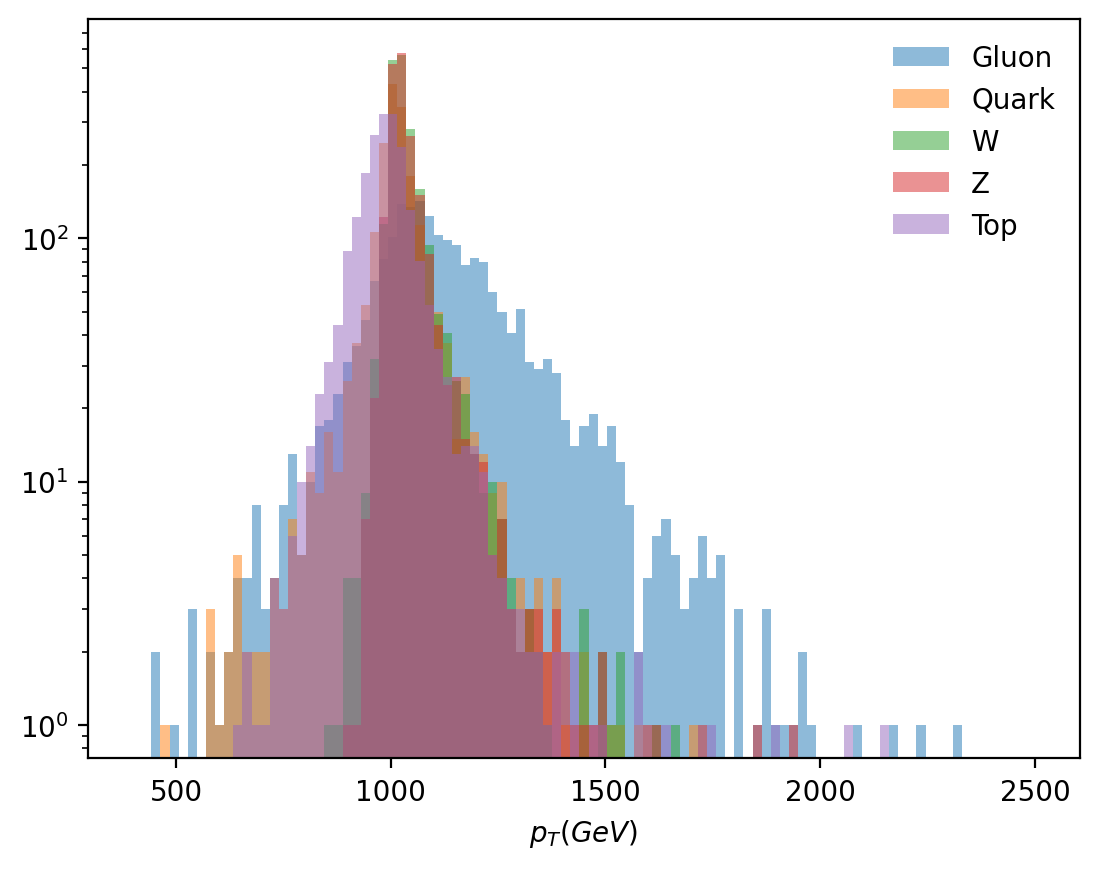

In [11]:
#Here we make new pandas DataFrames that only contain one type of event
pGluon=pJet.drop(pJet[pJet.j_g ==0].index)
pQuark=pJet.drop(pJet[pJet.j_q ==0].index)
pW=pJet.drop(pJet[pJet.j_w ==0].index)
pZ=pJet.drop(pJet[pJet.j_z ==0].index)
pT=pJet.drop(pJet[pJet.j_t ==0].index)

#Here we are plotting how the transverse momentum looks for these event categories.
fig,ax = plt.subplots()
ax.hist(pGluon['j_pt'].to_numpy(),alpha=0.5,bins=np.linspace(400,2500,100),label="Gluon")
ax.hist(pQuark['j_pt'].to_numpy(),alpha=0.5,bins=np.linspace(400,2500,100),label="Quark")
ax.hist(pW['j_pt'].to_numpy(),alpha=0.5,bins=np.linspace(400,2500,100),label="W")
ax.hist(pZ['j_pt'].to_numpy(),alpha=0.5,bins=np.linspace(400,2500,100),label="Z")
ax.hist(pT['j_pt'].to_numpy(),alpha=0.5,bins=np.linspace(400,2500,100),label="Top")
ax.set_xlabel("$p_{T} (GeV)$")
ax.legend()
ax.set_yscale('log')

## Do the images look different for the different events?

In the code below we take the average image for the five different event types to show that there are some differences between the images.

In [12]:
#Take the average the np.array(pJeft['j_g'])[:,None,None] is required to turn the 1D array of 0's and 1's
# into a 3D array of 0's and 1's to multiply the images in jetImage
print(np.array(pJet['j_g'])[:,None, None].shape)
averageGluon=np.mean(df['jetImage']*np.array(pJet['j_g'])[:,None, None], axis =0)
averageQuark=np.mean(df['jetImage'][:]*np.array(pJet['j_q'])[:,None,None],axis=0)
averageW=np.mean(df['jetImage'][:]*np.array(pJet['j_w'])[:,None,None],axis=0)
averageZ=np.mean(df['jetImage'][:]*np.array(pJet['j_z'])[:,None,None],axis=0)
averageT=np.mean(df['jetImage'][:]*np.array(pJet['j_t'])[:,None,None],axis=0)
averageAll=np.mean(df['jetImage'][:],axis=0)


(10000, 1, 1)


In [13]:
print(averageGluon.shape)
print(np.where(pJet['j_g']==1))

(100, 100)
(array([   0,    7,    9, ..., 9992, 9993, 9997]),)


Text(0.5, 1.0, 'All')

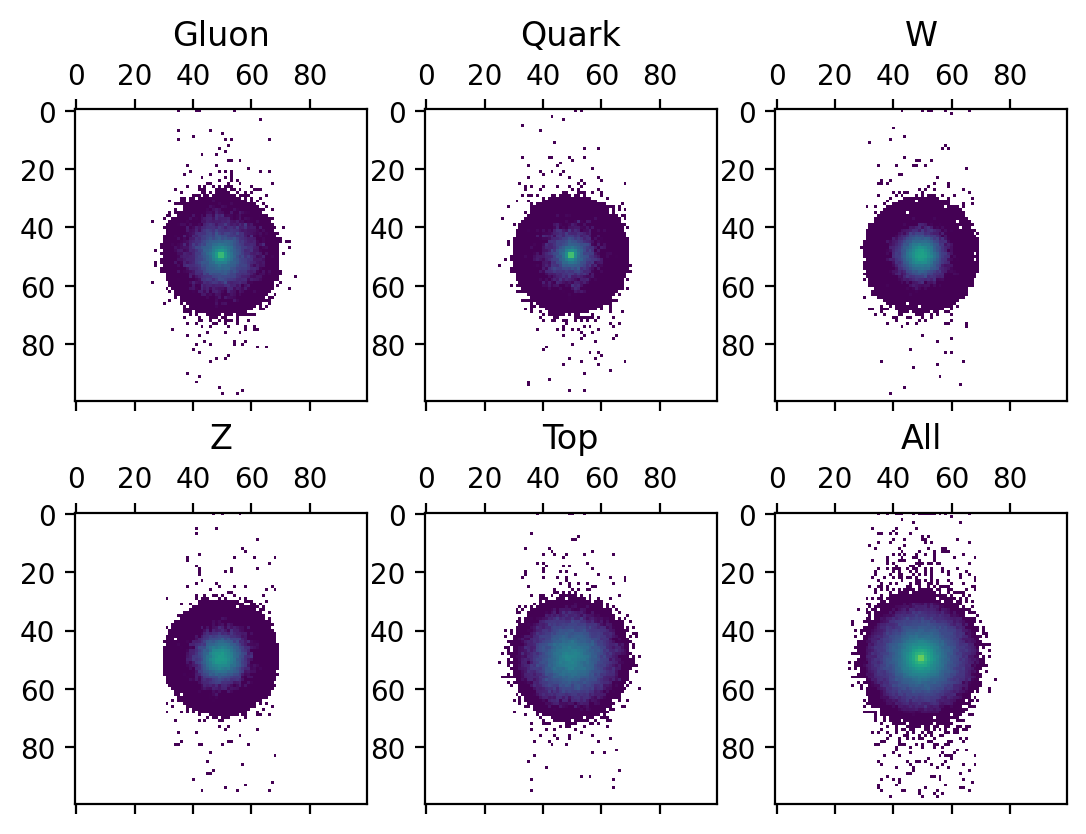

In [14]:
fig, ax = plt.subplots(2,3)
ax[0][0].matshow(averageGluon,norm=LogNorm(vmin=0.01, vmax=1e3))
ax[0][0].set_title("Gluon")
ax[0][1].matshow(averageQuark,norm=LogNorm(vmin=0.01, vmax=1e3))
ax[0][1].set_title("Quark")
ax[0][2].matshow(averageW,norm=LogNorm(vmin=0.01, vmax=1e3))
ax[0][2].set_title("W")
ax[1][0].matshow(averageZ,norm=LogNorm(vmin = 0.01, vmax = 1e3))
ax[1][0].set_title("Z")
ax[1][1].matshow(averageT,norm=LogNorm(vmin=0.01, vmax=1e3))
ax[1][1].set_title("Top")
ax[1][2].matshow(averageAll,norm=LogNorm(vmin=0.01, vmax=1e3))
ax[1][2].set_title("All")

# 1. Loading dataset from h5 files: #

In [15]:
def lognorm_transform(img, vmin=0.01, vmax=1e3):
    '''
    Log-normalises jet images to [0, 1] range.
    Clips values below vmin to vmin before taking log,
    avoiding -inf and the need for a separate masking step.
    '''
    log_min = np.log(vmin)
    log_max = np.log(vmax)

    img_clipped = np.clip(img, vmin, vmax).astype(np.float32)
    img_log     = np.log(img_clipped)

    return (img_log - log_min) / (log_max - log_min)

In [16]:
def load_single_h5_img(file_path, channels='combined'):
    '''
    Loads individual jet images from one h5 file.
    Applies lognorm_transform immediately so the returned
    array is already float32 in [0,1] — no second pass needed.

    Returns
    -------
    images     : float32 array, shape (N, 100, 100) or (N, 100, 100, 3)
    int_labels : int array,     shape (N,)   — 0=Gluon 1=Quark 2=W 3=Z 4=Top
    '''
    try:
        df = h5py.File(file_path, 'r')
    except Exception as e:
        print("Error opening file:", e)
        raise

    # Integer class labels from one-hot columns
    feat_names = [l.decode('utf-8') for l in df['jetFeatureNames'][:]]
    pJet       = pd.DataFrame(np.array(df['jets']), columns=feat_names)
    label_cols = ['j_g', 'j_q', 'j_w', 'j_z', 'j_t']
    int_labels = np.argmax(pJet[label_cols].to_numpy(), axis=1)

    # Load images and transform immediately — before appending to the list
    if channels == 'combined':
        raw    = np.array(df['jetImage'][:])
        images = lognorm_transform(raw)                        # (N, 100, 100)

    elif channels == 'all':
        ch0 = lognorm_transform(np.array(df['jetImage'][:]))
        ch1 = lognorm_transform(np.array(df['jetImageECAL'][:]))
        ch2 = lognorm_transform(np.array(df['jetImageHCAL'][:]))
        images = np.stack([ch0, ch1, ch2], axis=-1)           # (N, 100, 100, 3)

    else:
        raise ValueError(f"channels must be 'combined' or 'all', got '{channels}'")

    df.close()
    return images, int_labels


In [17]:
def load_many_h5_files(main_dir, max_files=None, dataset_type="train",
                       save_dir=".", channels='combined'):
    '''
    Loads all .h5 files in a directory and saves combined arrays as .npy files.

    Parameters
    ----------
    main_dir : str
        Directory containing .h5 files.
    max_files : int or None
        Limit number of files loaded. None loads all.
    dataset_type : str
        Used in output filenames e.g. "train", "validation", "test".
    save_dir : str
        Directory where .npy files are saved.
    channels : str
        Passed through to load_single_h5_img.
        'combined' → single jetImage channel  (Task 1)
        'all'      → three calorimeter channels (Extension 1)

    Returns
    -------
    all_images : np.ndarray   shape (N_total, 100, 100) or (N_total, 100, 100, 3)
    all_labels : np.ndarray   shape (N_total,)  integer class labels 0–4
    '''

    all_images = []
    all_labels = []
    file_count = 0

    h5_files = sorted([f for f in os.listdir(main_dir) if f.endswith('.h5')])

    for file in h5_files:

        if max_files is not None and file_count >= max_files:
            break

        file_path = os.path.join(main_dir, file)

        try:
            images, labels = load_single_h5_img(file_path, channels=channels)
            all_images.append(images)
            all_labels.append(labels)
            file_count += 1
            print(f"Loaded {file_path}  ({images.shape[0]:,} jets)")

        except Exception as e:
            print(f"Skipping {file_path}: {e}")
            continue

    all_images = np.concatenate(all_images, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Verify class balance before saving
    unique, counts = np.unique(all_labels, return_counts=True)
    class_names = ['Gluon', 'Quark', 'W', 'Z', 'Top']
    print("\nClass distribution:")
    for cls, cnt in zip(unique, counts):
        print(f"  {class_names[cls]:6s}: {cnt:,}")

    # Save
    #images_file = os.path.join(save_dir, f"{dataset_type}_images.npy")
    #labels_file = os.path.join(save_dir, f"{dataset_type}_labels.npy")
    #np.save(images_file, all_images)
    #np.save(labels_file, all_labels)

    #print(f"\nSaved {all_images.shape} → {images_file}")
   # print(f"Saved {all_labels.shape} → {labels_file}")
    print(f"Total: {file_count} files, {all_images.shape[0]:,} jets")

    return all_images, all_labels

In [18]:
## Loading data ##

val_images = np.load(main_dir + "/datasets/validation_images.npy")
val_labels = np.load(main_dir + "/datasets/validation_labels.npy")

#Train + Test Dataset
data_images = np.load(main_dir +"/datasets/train_images.npy")
data_labels = np.load(main_dir +"/datasets/train_labels.npy")

In [19]:
val_images.shape, val_labels.shape, data_images.shape, data_labels.shape

((30000, 100, 100), (30000,), (80000, 100, 100), (80000,))

In [20]:
val_images = val_images[...,np.newaxis]
data_images = data_images[...,np.newaxis]

val_images.shape, data_images.shape

((30000, 100, 100, 1), (80000, 100, 100, 1))

In [22]:
 #shuffling data #

val_images, val_labels = shuffle(val_images, val_labels, random_state = 42)
data_images, data_labels = shuffle(data_images, data_labels, random_state=42)

In [23]:
print(data_images.shape)

(80000, 100, 100, 1)


In [24]:
#Making Train and Test Dataset

split = int(0.8*len(data_images))

#Train dataset

train_images = data_images[:split]
train_labels = data_labels[:split]

#Test dataset

test_images = data_images[split:]
test_labels = data_labels[split:]

train_images.shape, train_labels.shape, test_images.shape, test_labels.shape,

((64000, 100, 100, 1), (64000,), (16000, 100, 100, 1), (16000,))

In [25]:
val_images.shape, val_labels.shape

((30000, 100, 100, 1), (30000,))

Text(0.5, 1.0, 'Top')

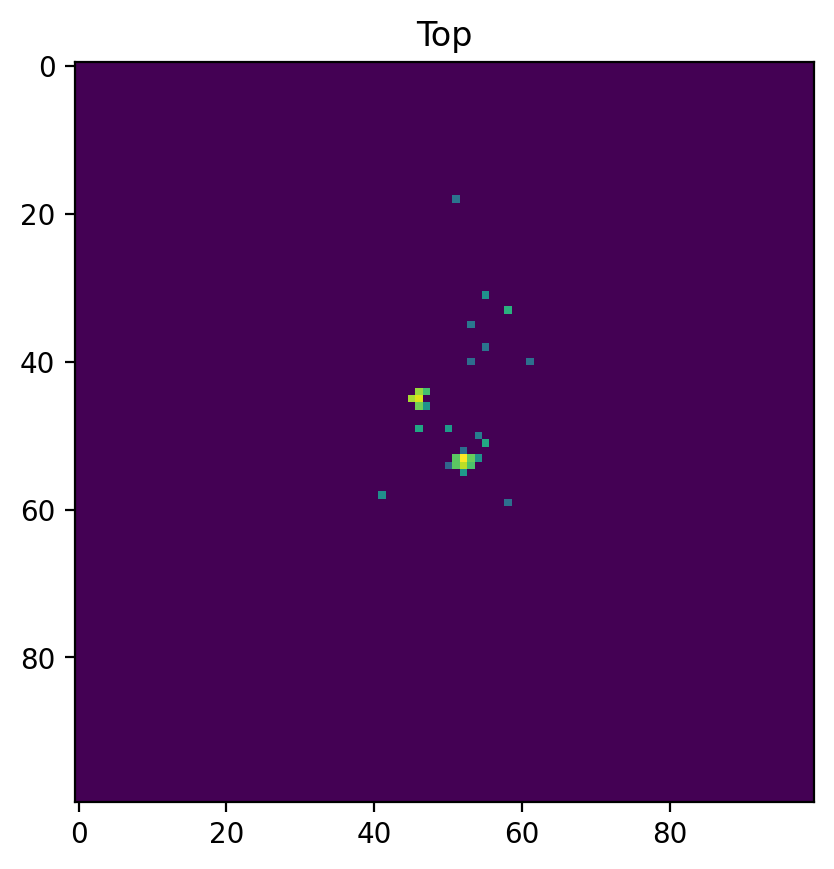

In [26]:
#labels#

class_names = ['Gluon', 'Quark', 'W', 'Z', 'Top']

plt.imshow(train_images[1])
plt.title(class_names[train_labels[1]])

In [27]:
# Run this cell before model.fit and read every line of output
print("Shape:", train_images.shape)        # must be (N, 100, 100, 1)
print("dtype:", train_images.dtype)        # must be float32
print("min/max:", train_images.min(), train_images.max())  # must be 0.0 to 1.0
print("labels:", np.unique(train_labels, return_counts=True))  # must show 5 classes
print("first 10 labels:", train_labels[:10])

Shape: (64000, 100, 100, 1)
dtype: float32
min/max: 0.0 1.0000001
labels: (array([0, 1, 2, 3, 4]), array([12925, 12398, 12798, 12899, 12980]))
first 10 labels: [3 4 2 3 1 4 0 1 4 2]


# Test 1: Running first test model #

In [28]:
def build_jet_cnn_v1(input_shape = (100,100, 1) , n_classes = 5):
    '''

    General model for an image classification model
    - Look at week 4 - REDO USING A CONVOLUTION NEURAL NETWORK

    Input:

    Input_shape =
    input_x = x dimension of input image matrix
    input_y = y dimensino of input image matrix
    channels =
             1=> if we are only looking at Full image
             3=> if we are look at Full Image, ECAL and HCAL
    n_classes = no. of output nodes

    Ouput:
    Returns model using a softmax activation function at the output nodes for
    image classification

    '''

    l2_reg = keras.regularizers.l2(1e-4)

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=input_shape))

    model.add(keras.layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=l2_reg))
    model.add(keras.layers.LeakyReLU(alpha=0.1))
    model.add(keras.layers.MaxPooling2D((2,2)))

    model.add(keras.layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=l2_reg))
    model.add(keras.layers.LeakyReLU(alpha=0.1))
    model.add(keras.layers.MaxPooling2D((2,2)))

    model.add(keras.layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=l2_reg))
    model.add(keras.layers.LeakyReLU(alpha=0.1))
    model.add(keras.layers.MaxPooling2D((2,2)))

    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(256, kernel_regularizer=l2_reg))
    model.add(keras.layers.LeakyReLU(alpha=0.1))
    model.add(keras.layers.Dropout(0.3))
    model.add(keras.layers.Dense(n_classes))

    model.summary()

    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    return model



# Test 1: Sanity Check #

First model will be ran with inital basic model and 64 epochs, with 64 batch_size

In [29]:
# Sanity check — should see loss drop within 3 epochs if pipeline is working
model_test = build_jet_cnn_v1(input_shape=(100, 100, 1), n_classes=5)
model_test.fit(
    train_images[:1000], train_labels[:1000],
    validation_data=(val_images[:200], val_labels[:200]),
    epochs=5,
    batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,812,805 (18.36 MB)

 Trainable params: 4,812,805 (18.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.3490 - loss: 1.4646 - val_accuracy: 0.5300 - val_loss: 1.3369
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4920 - loss: 1.2100 - val_accuracy: 0.5100 - val_loss: 1.2505
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5730 - loss: 1.0633 - val_accuracy: 0.4550 - val_loss: 1.3798
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5920 - loss: 1.0183 - val_accuracy: 0.5350 - val_loss: 1.1452
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6240 - loss: 0.9306 - val_accuracy: 0.5100 - val_loss: 1.2123


In [30]:
# Paste these prints directly above model_v1.fit — same cell
print("train shape:", train_images.shape)   # must be (80000, 100, 100, 1)
print("val shape:  ", val_images.shape)     # must be (40000, 100, 100, 1)
print("train labels:", np.unique(train_labels, return_counts=True))

train shape: (64000, 100, 100, 1)
val shape:   (30000, 100, 100, 1)
train labels: (array([0, 1, 2, 3, 4]), array([12925, 12398, 12798, 12899, 12980]))


In [31]:
model_v1 = build_jet_cnn_v1(input_shape=(100, 100, 1), n_classes=5)

model_v1_dir = main_dir + "/Results/Model_v1"

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model_v1.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    epochs=200,
    batch_size=64,   # larger batch = fewer steps per epoch = faster on CPU
    callbacks=[early_stop]
)


model_v1.save(model_v1_dir+ '/jet_cnn_v1.keras')


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,812,805 (18.36 MB)

 Trainable params: 4,812,805 (18.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.6206 - loss: 1.0043 - val_accuracy: 0.6701 - val_loss: 0.9287
Epoch 2/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.6797 - loss: 0.9102 - val_accuracy: 0.6772 - val_loss: 0.8996
Epoch 3/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.6979 - loss: 0.8802 - val_accuracy: 0.7056 - val_loss: 0.8698
Epoch 4/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.7129 - loss: 0.8553 - val_accuracy: 0.7067 - val_loss: 0.8698
Epoch 5/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.7209 - loss: 0.8401 - val_accuracy: 0.7120 - val_loss: 0.8562
Epoch 6/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.7286 - loss: 0.8289 - val_accuracy: 0.7185 - val_loss: 0.8485
Epoch 7/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.7345 - loss: 0.8141 - val_accuracy: 0.7105 - val_loss: 0.8620
Epoch 8/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 

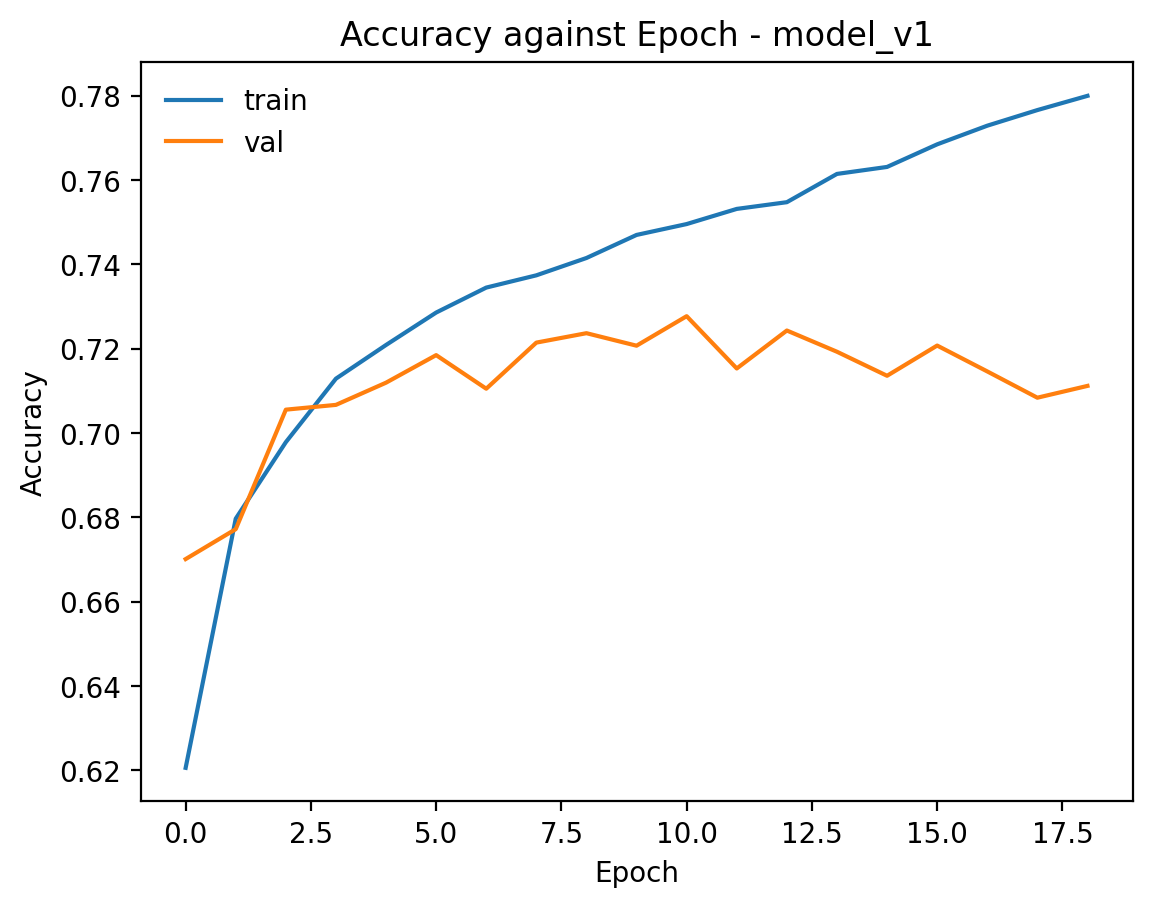

In [32]:
# Plot training curve to see how accuracy training compared with validation
plt.figure()
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy against Epoch - model_v1")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(model_v1_dir + '/Plots/acc_epoch_plot_model_v1.pdf', bbox_inches='tight')
plt.show()


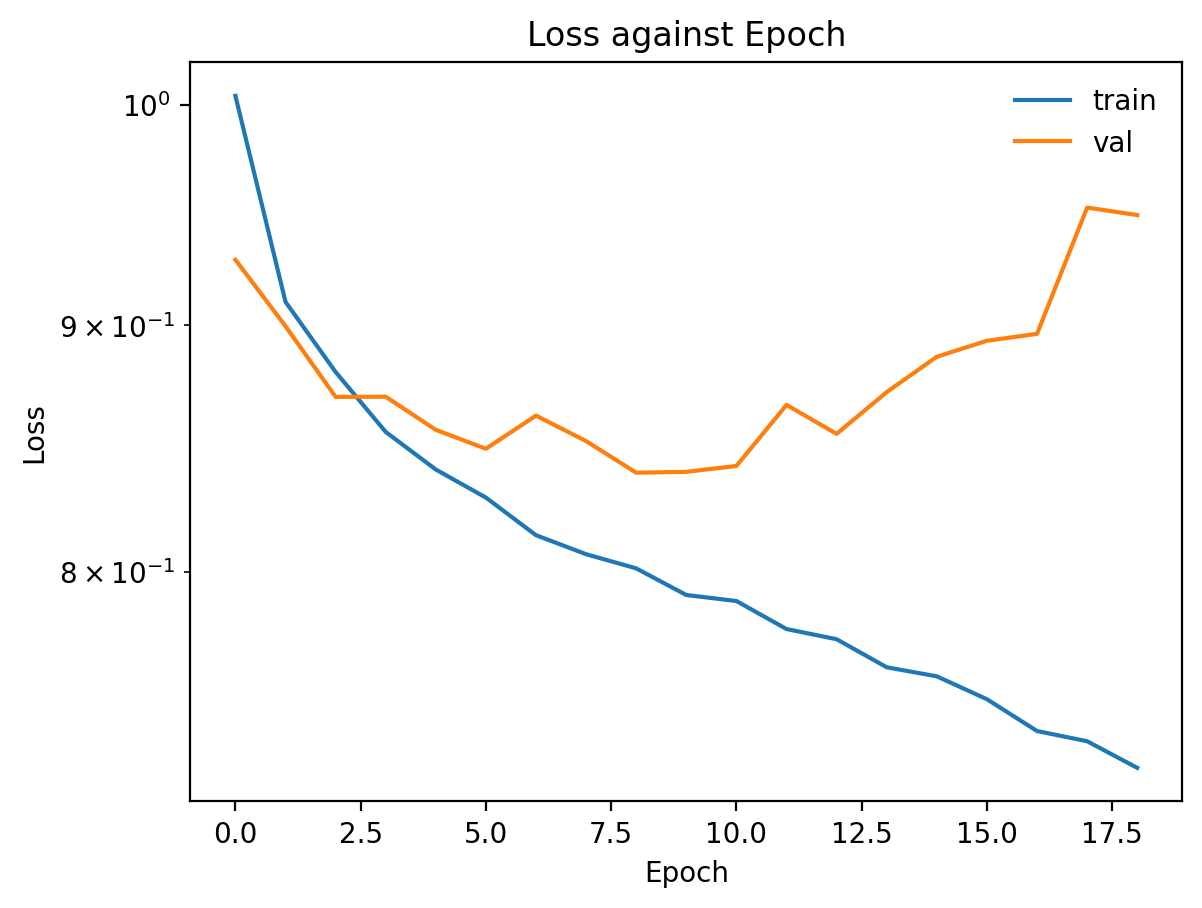

In [33]:
# Plot training curve to see how accuracy training compared with validation
plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss against Epoch")
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(model_v1_dir + '/Plots/loss_epoch_plot_model_v1.pdf', bbox_inches='tight')
plt.show()


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

       Gluon     0.7218    0.6763    0.6983      3268
       Quark     0.6623    0.6970    0.6792      3079
           W     0.7097    0.8024    0.7532      3229
           Z     0.7707    0.6949    0.7308      3081
         Top     0.8076    0.7897    0.7985      3343

    accuracy                         0.7330     16000
   macro avg     0.7344    0.7321    0.7320     16000
weighted avg     0.7352    0.7330    0.7329     16000



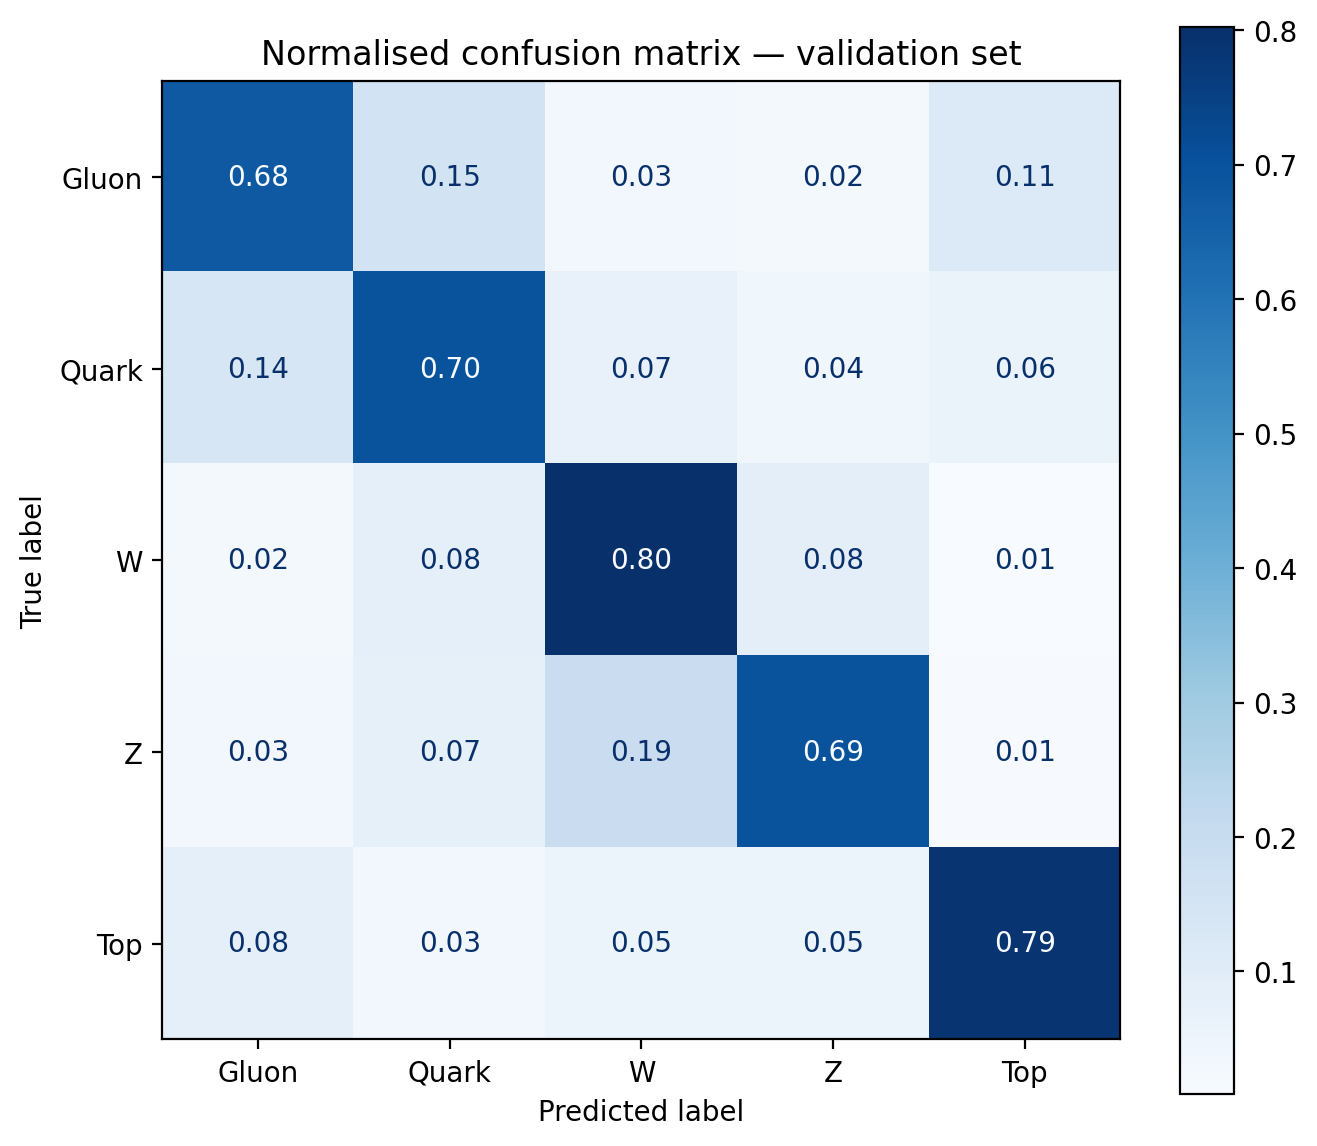

In [34]:
## Adding confusion matrix and classification report metrics

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

logits      = model_v1.predict(test_images, batch_size=64)
pred_labels = np.argmax(logits, axis=1)

# Per-class precision, recall, F1
print(classification_report(test_labels, pred_labels,
      target_names=['Gluon','Quark','W','Z','Top'], digits=4))

# Confusion matrix
cm = confusion_matrix(test_labels, pred_labels, normalize='true')
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=['Gluon','Quark','W','Z','Top']).plot(
    ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title("Normalised confusion matrix — validation set")
plt.tight_layout()
plt.savefig(model_v1_dir + '/Plots/confusion_matrix_model_v1.pdf', bbox_inches='tight')
plt.show()

In [35]:
print(classification_report(
    test_labels, pred_labels,
    target_names=['Gluon', 'Quark', 'W', 'Z', 'Top'],
    digits=4
))

              precision    recall  f1-score   support

       Gluon     0.7218    0.6763    0.6983      3268
       Quark     0.6623    0.6970    0.6792      3079
           W     0.7097    0.8024    0.7532      3229
           Z     0.7707    0.6949    0.7308      3081
         Top     0.8076    0.7897    0.7985      3343

    accuracy                         0.7330     16000
   macro avg     0.7344    0.7321    0.7320     16000
weighted avg     0.7352    0.7330    0.7329     16000



In [36]:
test_loss, test_acc = model_v1.evaluate(test_images, test_labels, batch_size=64)

print(f"Final test accuracy: {test_acc:.4f}")
print(f"Final test loss:     {test_loss:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7330 - loss: 0.8269
Final test accuracy: 0.7330
Final test loss:     0.8269


# ROC Curves and AUC: #


1. **ROC curve — Receiver Operating Characteristic curve** - plots the trade-off between two things as you vary the classification threshold
     - **True Positive Rate (TPR)** on the y-axis — out of all real W jets, what fraction did you correctly identify as W? Also called sensitivity or recall.
     - **False Positive Rate (FPR)** on the x-axis — out of all non-W jets, what fraction did you wrongly call W?
2. **AUC — Area Under the Curve** - AUC is a single number that summarises the entire ROC curve
     - **AUC = 1.0** -> perfect classifier
     - **AUC = 0.5** -> no better than random guessing
     - Expectation: model should land between 0.85-0.95 depending on the class

In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

CLASS_NAMES = ['Gluon', 'Quark', 'W', 'Z', 'Top']
N_CLASSES   = 5

# model outputs logits — convert to probabilities with softmax
logits = model_v1.predict(test_images, batch_size=64)
probs  = tf.nn.softmax(logits).numpy()        # shape (N, 5), each row sums to 1

# Binarize labels for one-vs-rest ROC
# e.g. true label 2 (W) becomes [0, 0, 1, 0, 0]
test_labels_bin = label_binarize(test_labels, classes=list(range(N_CLASSES)))

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [38]:
# Store fpr, tpr, auc for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(N_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(
        test_labels_bin[:, i],   # true binary label for class i
        probs[:, i]             # predicted probability for class i
    )
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f"AUC {CLASS_NAMES[i]:6s}: {roc_auc[i]:.4f}")

# Macro-averaged AUC — single headline number for the report
macro_auc = np.mean(list(roc_auc.values()))
print(f"\nMacro-averaged AUC: {macro_auc:.4f}")

AUC Gluon : 0.9215
AUC Quark : 0.9057
AUC W     : 0.9373
AUC Z     : 0.9233
AUC Top   : 0.9507

Macro-averaged AUC: 0.9277


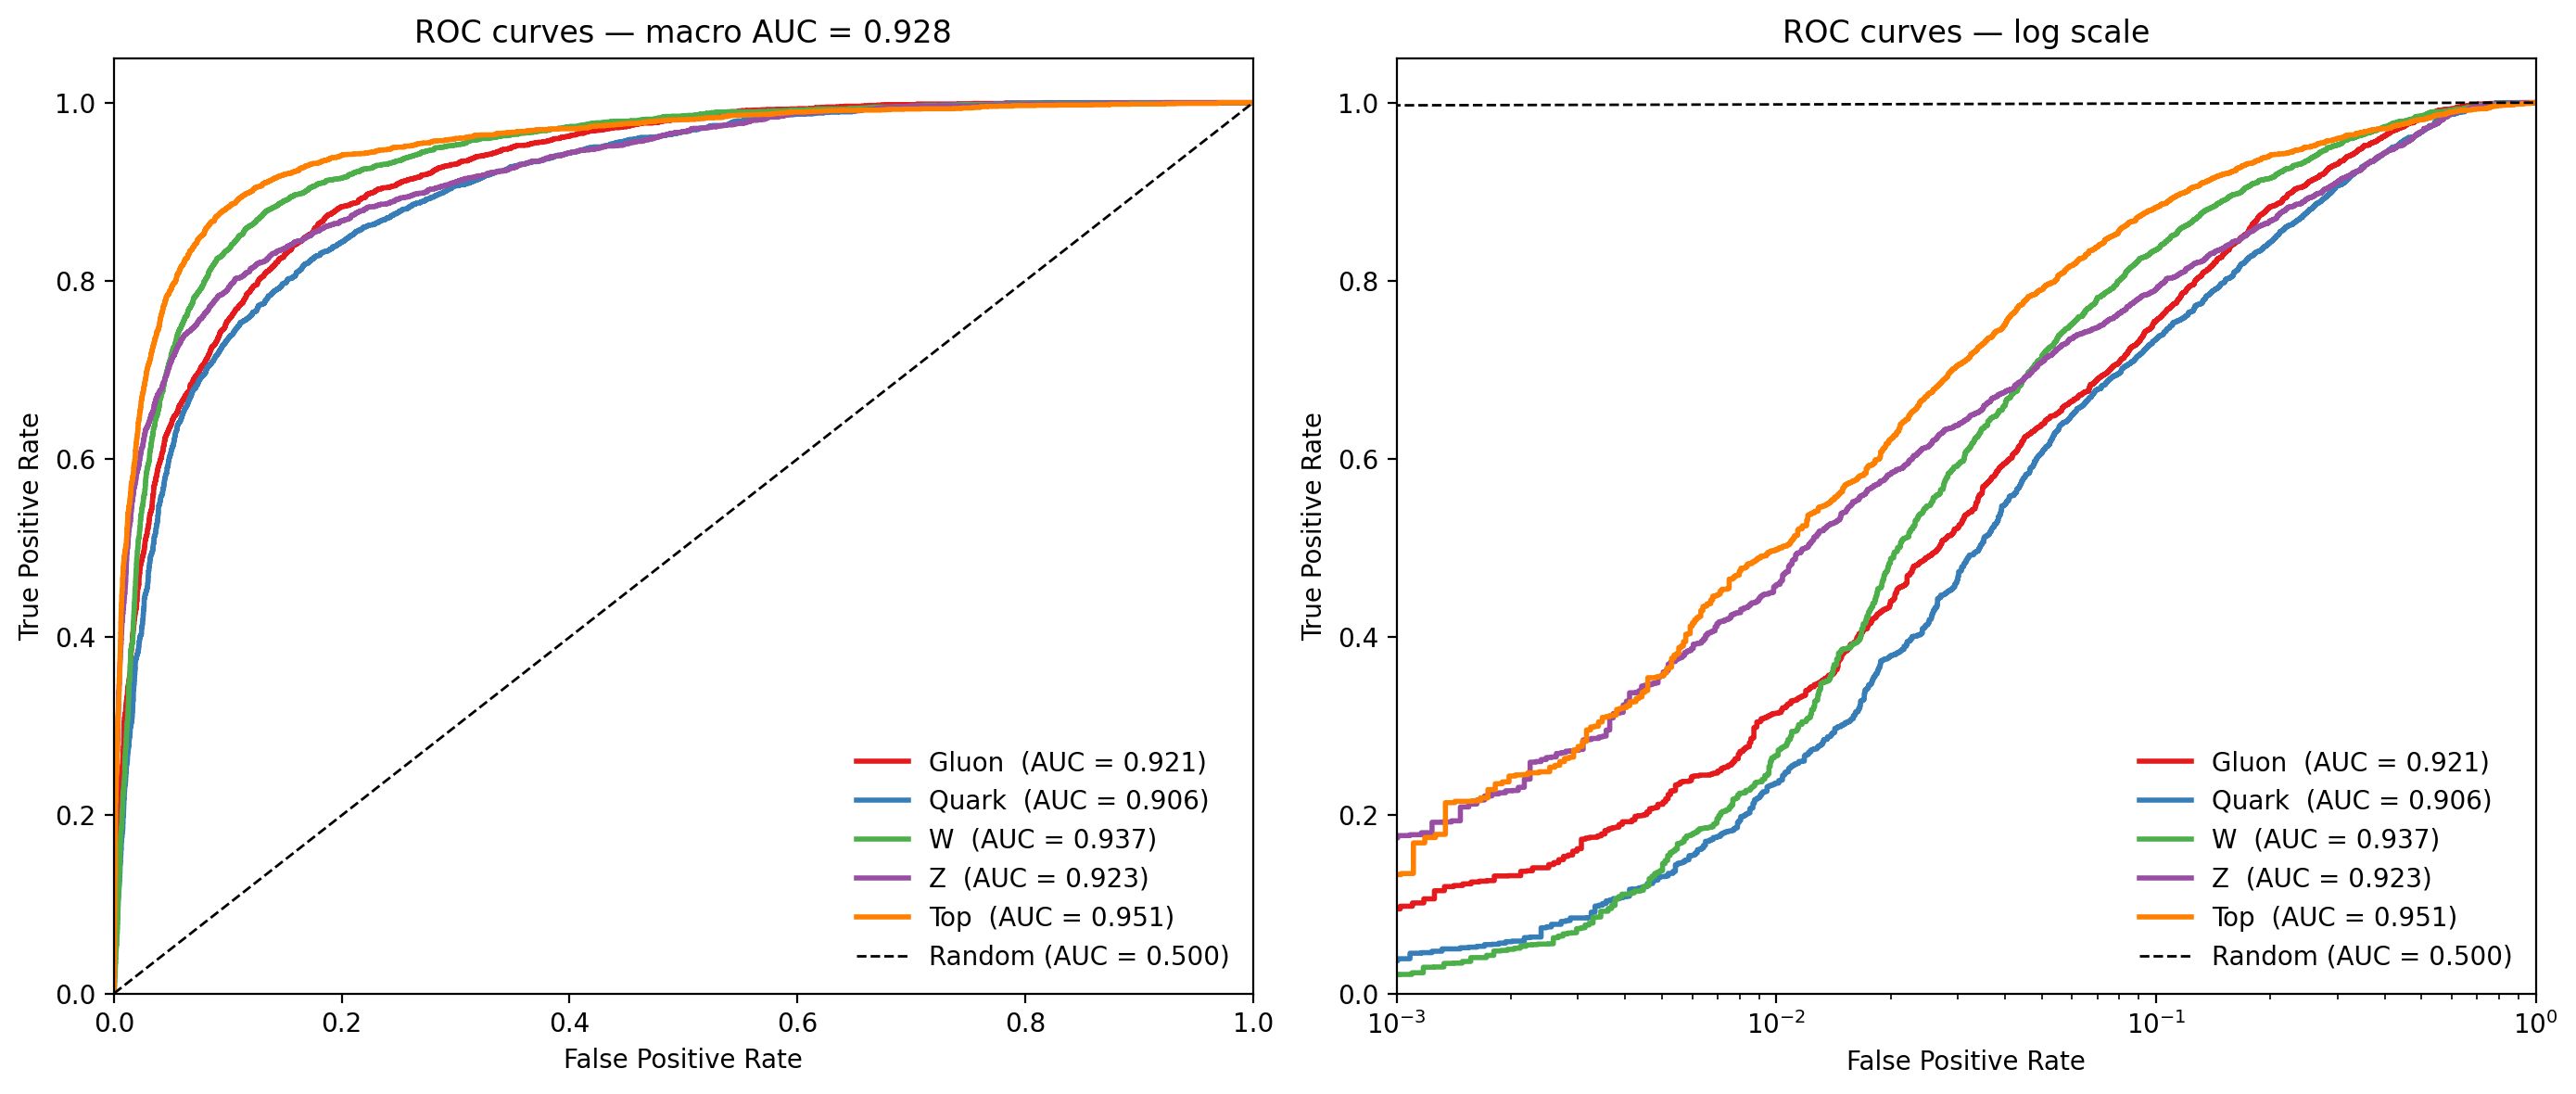

In [41]:

COLOURS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

#Plotting Graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, logscale in zip(axes, [False, True]):
    for i in range(N_CLASSES):
        ax.plot(fpr[i], tpr[i], color=COLOURS[i], linewidth=2,
                label=f"{CLASS_NAMES[i]}  (AUC = {roc_auc[i]:.3f})")

    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC = 0.500)')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right')
    ax.set_ylim([0.0, 1.05])

    if logscale:
        ax.set_xscale('log')
        ax.set_xlim([1e-3, 1.0])
        ax.set_title(f"ROC curves — log scale")
    else:
        ax.set_xlim([0.0, 1.0])
        ax.set_title(f"ROC curves — macro AUC = {macro_auc:.3f}")

plt.tight_layout()
plt.savefig(model_v1_dir + '/Plots/roc_curves_both.pdf', bbox_inches='tight')
plt.show()
